In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Features we'll use
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Pclass']

X = df[numerical_features + categorical_features]
y = df['Survived']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing for numerical columns: fill missing values, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns: fill missing values, then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [7]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [8]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Accuracy: {accuracy:.2%}")

Pipeline Accuracy: 79.89%


In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [10]:
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
categorical_features = ['Sex', 'Embarked', 'Pclass', 'IsAlone']

X = df[numerical_features + categorical_features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline.fit(X_train, y_train)
y_pred_new = model_pipeline.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred_new)
print(f"Pipeline Accuracy with Engineered Features: {new_accuracy:.2%}")

Pipeline Accuracy with Engineered Features: 79.89%


In [11]:
import joblib

joblib.dump(model_pipeline, 'titanic_pipeline.pkl')

['titanic_pipeline.pkl']

## Why Pipelines Matter

A pipeline bundles preprocessing and modeling into a single object, so
every step is applied consistently and in the correct order every time.
This prevents a common mistake called data leakage, where information
from the test set accidentally influences how the training data is
processed. It also makes the code more reusable — the entire pipeline
can be saved and reloaded to make predictions on new data without
rewriting any preprocessing steps manually.

In [12]:
!pip install xgboost --quiet

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

# Same cleaning as Task 2
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

# Encode categorical columns
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

# Your original Logistic Regression model from Task 3 (retrain here for direct comparison)
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

Logistic Regression Accuracy: 0.8100558659217877
Random Forest Accuracy: 0.8212290502793296
XGBoost Accuracy: 0.8044692737430168


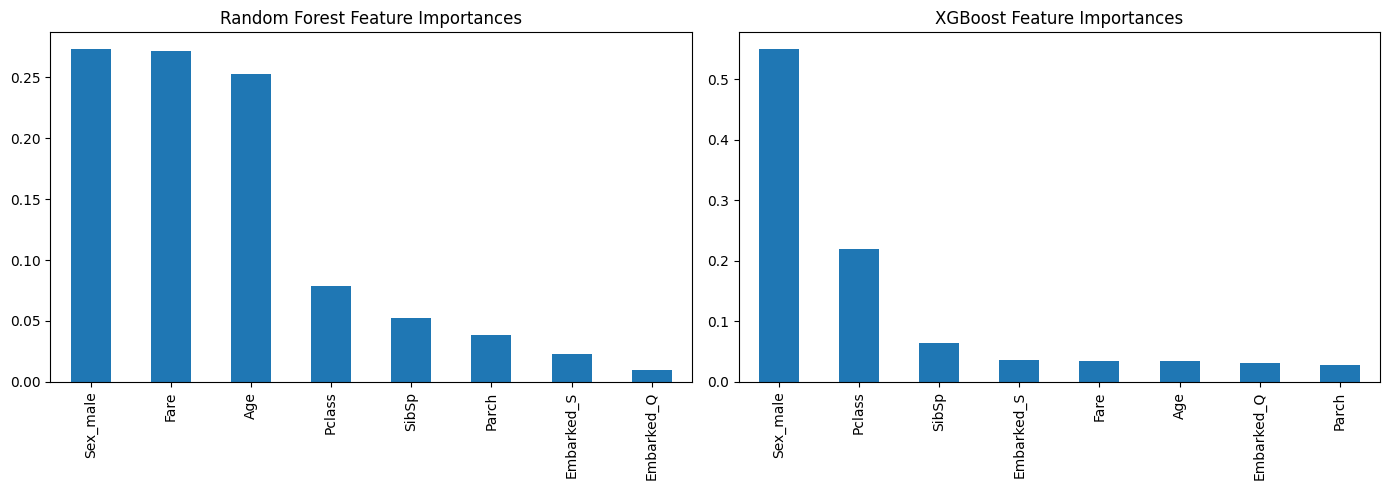

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Random Forest importances
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importances.plot(kind='bar', ax=axes[0], title='Random Forest Feature Importances')

# XGBoost importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importances.plot(kind='bar', ax=axes[1], title='XGBoost Feature Importances')

plt.tight_layout()
plt.show()

## How Random Forest and XGBoost Differ

Random Forest builds many decision trees independently and in parallel,
each trained on a random subset of data and features, then combines their
predictions through majority voting. XGBoost instead builds trees
sequentially, where each new tree focuses specifically on correcting the
errors made by the previous trees, gradually improving the model step by
step. This is why XGBoost is called a "boosting" method, while Random
Forest is called a "bagging" method. In practice, XGBoost often achieves
slightly higher accuracy since it directly targets its own mistakes, but
it can also be more prone to overfitting if not carefully tuned, while
Random Forest tends to be more stable out of the box.

## Model Comparison

| Model | Metric | Score |
|---|---|---|
| Logistic Regression | Accuracy | 81.01% |
| Random Forest | Accuracy | 82.12% |
| XGBoost | Accuracy | 80.45% |

Random Forest performed slightly best on this dataset, followed closely
by Logistic Regression, with XGBoost marginally behind. The differences
are small, likely because the Titanic dataset is relatively small and
simple, so the more complex ensemble models don't have a huge advantage
over a well-tuned simpler model. On larger, more complex datasets,
XGBoost and Random Forest typically show a bigger performance edge
over single models like Logistic Regression.